# Lactation Autoencoder: Complete Data Pipeline

This notebook demonstrates the end-to-end lactation ML pipeline from raw JSON data to model-ready batches.

Uses bovi-core's config-driven architecture (no hardcoded paths).

## Section 1: Setup & Initialize Config

In [5]:
from bovi_core.config import Config
from bovi_core.ml import ModelRegistry

# With auto-discovery, no manual import needed — bovi-core finds registered models automatically
config = Config(experiment_name="lactation_autoencoder", project_name="lactation-autoencoder")
print(f"Environment: {config.environment}")
print(f"Project root: {config.project.project_root}")

# Show all auto-discovered models
print(f"\nRegistered models: {ModelRegistry.list_available()}")

Environment: local
Project root: /Users/douwedekok/Documents/work/code_work/bovi/bovi-models-douwe


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader

np.set_printoptions(precision=3, suppress=True, threshold=10)
print("Libraries loaded")

Libraries loaded


In [7]:
# Access config via config.run (NOT get_experiment_config)
print(f"experiment_name: {config.experiment.experiment_name}")
print(f"max_days: {config.experiment.dataset.max_days}")
print(f"batch_size: {config.experiment.dataloaders.inference.dataloader.batch_size}")

experiment_name: lactation_autoencoder
max_days: 304
batch_size: 1


## Section 2: Load Data Source

In [ ]:
from pathlib import Path

from lactation_autoencoder.dataloaders.sources.lactation_pkl_source import LactationPKLSource

# Use inference dataloader (has actual data in input/inference/)
source_config = config.experiment.dataloaders.inference.source
json_dir = Path(config.project.project_root) / source_config.json_root_dir
herd_stats_dir = Path(config.project.project_root) / source_config.herd_stats_dir

source = LactationPKLSource(
    json_root_dir=json_dir,
    herd_stats_dir=herd_stats_dir,
    file_pattern=source_config.file_pattern,
    keep_in_memory=config.experiment.dataset.keep_in_memory
)

print(f"Loaded {len(source)} lactations")
print(f"Events: {len(source.event_to_idx)}")
print(f"Herd stats params: {len(source.idx_to_herd_par)}")

In [9]:
# Inspect raw data
raw_item = source.load_item(0)

print("Raw data keys:")
for key in raw_item.keys():
    value = raw_item[key]
    if isinstance(value, np.ndarray):
        print(f"  {key}: ndarray{value.shape}")
    elif isinstance(value, list):
        print(f"  {key}: list[{len(value)}]")
    elif isinstance(value, dict):
        print(f"  {key}: dict[{len(value)}]")
    else:
        print(f"  {key}: {type(value).__name__}")

Raw data keys:
  animal_id: str
  parity: int
  herd_id: int
  milk: list[316]
  events: list[300]
  herd_stats: ndarray(10,)
  event_to_idx: dict[15]


## Section 3: Transform Pipeline

In [10]:
from bovi_core.ml.dataloaders.transforms.registry import TransformRegistry

# Build transforms from config (one line!)
# Returns OrderedDict: access by name or iterate in order
transforms = TransformRegistry.from_config(config.experiment.dataloaders.inference.transforms)

print(f"Created {len(transforms)} transforms:")
for name in transforms:
    print(f"  - {name}")

Created 3 transforms:
  - imputation
  - event_tokenization
  - milk_normalization


In [ ]:
# Show transform effects - Transform 1: Imputation
print("Transform 1: Imputation")
milk_before = raw_item['milk'].copy()
none_count = sum(1 for x in milk_before if x is None or (isinstance(x, float) and np.isnan(x)))
print(f"  Before: {none_count} missing values")

# Use the already-created transform from the OrderedDict
data_imputed = transforms['imputation'](raw_item.copy())
milk_after = data_imputed['milk']
none_count_after = sum(1 for x in milk_after if x is None or (isinstance(x, float) and np.isnan(x)))
print(f"  After: {none_count_after} missing values")

In [ ]:
# Transform 2: Event Tokenization
print("Transform 2: Event Tokenization")
events_before = raw_item['events'][:10]
print(f"  Before: {events_before}")

# Use the already-created transform
data_tokenized = transforms['event_tokenization'](data_imputed.copy())
events_after = data_tokenized.get('events_encoded', data_tokenized['events'])[:10]
print(f"  After: {events_after}")

In [ ]:
# Transform 3: Milk Normalization
print("Transform 3: Milk Normalization")
milk_raw = np.array(data_imputed['milk'])
print(f"  Before: min={milk_raw.min():.2f}, max={milk_raw.max():.2f}")

# Use the already-created transform
data_normalized = transforms['milk_normalization'](data_tokenized.copy())
milk_normalized = np.array(data_normalized['milk'])
print(f"  After: min={milk_normalized.min():.3f}, max={milk_normalized.max():.3f}")

## Section 4: Create Dataset

In [ ]:
from bovi_core.ml.dataloaders.sources import TransformedSource
from lactation_autoencoder.dataloaders.datasets.lactation_dataset import LactationDataset

# Wrap source with transforms (following "Datasets are Dumb" principle)
# Convert OrderedDict values to list for TransformedSource
transformed_source = TransformedSource(source, list(transforms.values()))

max_days = config.experiment.dataset.max_days
dataset = LactationDataset(
    source=transformed_source,
    config=config,
    max_days=max_days
)

print(f"Dataset: {len(dataset)} samples, {max_days} days per sequence")

In [11]:
# Inspect dataset output
item = dataset[0]

print("Dataset output structure:")
print(f"  features keys: {list(item['features'].keys())}")
for fname, fvalue in item['features'].items():
    print(f"    {fname}: shape={fvalue.shape}, dtype={fvalue.dtype}")
print(f"  labels: shape={item['labels'].shape}, dtype={item['labels'].dtype}")
if 'metadata' in item:
    print(f"  metadata: {list(item['metadata'].keys())}")

Dataset output structure:
  features keys: ['milk', 'events', 'parity', 'herd_stats']
    milk: shape=(304,), dtype=float32
    events: shape=(304,), dtype=int32
    parity: shape=(1,), dtype=float32
    herd_stats: shape=(10,), dtype=float32
  labels: shape=(304,), dtype=float32
  metadata: ['index', 'animal_id', 'herd_id', 'parity']


In [12]:
# Verify consistency across samples (if multiple samples exist)
print("Consistency check across samples:")
if len(dataset) > 0:
    # Create list of indices to check: first, last, and middle (if exists)
    indices_to_check = [0]
    if len(dataset) > 1:
        indices_to_check.append(len(dataset) - 1)
    if len(dataset) > 2:
        indices_to_check.append(len(dataset) // 2)

    for idx in indices_to_check:
        item = dataset[idx]
        features = item['features']
        print(f"  Sample {idx}: milk={features['milk'].shape}, events={features['events'].shape}")
else:
    print("  No samples in dataset")

Consistency check across samples:
  Sample 0: milk=(304,), events=(304,)


## Section 5: Create DataLoader

In [ ]:
from lactation_autoencoder.dataloaders.datasets import collate_lactation_batch

batch_size = config.experiment.dataloaders.inference.dataloader.batch_size
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,  # No shuffle for inference
    collate_fn=collate_lactation_batch,
    num_workers=0
)

print(f"DataLoader: {len(dataloader)} batches of {batch_size}")

In [ ]:
# Inspect batch
batch = next(iter(dataloader))

print("Batch structure:")
for key, value in batch.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
    elif isinstance(value, list):
        print(f"  {key}: {len(value)} items")
    else:
        print(f"  {key}: {type(value).__name__}")

## Section 6: Load Model & Make Predictions

In [ ]:
# --- Method 1: Explicit registry (full control) ---
# No "import lactation_autoencoder" needed. When we call .get("autoencoder") or
# .create("autoencoder"), the registry reads pyproject.toml entry points to find
# which package provides "autoencoder", imports only that package, and triggers the
# @register decorator. This means tensorflow is only loaded when you request the model.
from bovi_core.ml import ModelRegistry, PredictorRegistry

# .create() returns an instance — predictors are simple (just need config)
predictor = PredictorRegistry.create("autoencoder", config=config)

# .get() returns the class — models need .from_config() for complex
# initialization (weights path resolution, device selection, etc.)
LactationModel = ModelRegistry.get("autoencoder")

# Option A: from_config() — reads weights path, location, framework from config.yaml
model = LactationModel.from_config(config=config, predictor=predictor)

# Option B: manual constructor — full control over every parameter
# model = LactationModel(
#     config=config,
#     weights_path="data/experiments/lactation_autoencoder/versions/v15/weights/model",
#     predictor=predictor,
#     weights_location="local",
#     model_type="tensorflow",
#     verbose=1,
# )

print(f"Model loaded: {model.model_name}")
print(f"Weights: {model.weights_path}")

In [ ]:
# --- Method 2: create_model() one-liner (simplest) ---
# Handles predictor creation + model discovery + from_config() in one call
from bovi_core.ml import create_model

model = create_model(config, "autoencoder")

print(f"Model loaded: {model.model_name}")
print(f"Weights: {model.weights_path}")

In [16]:
# Get the processed sample from dataset
# The dataset has already:
#   1. Loaded the JSON data (animal_001.json)
#   2. Applied all transforms (imputation, tokenization, normalization)
#   3. Padded/truncated to exactly 304 days
#   4. Structured as features/labels dict
item = dataset[0]

# Extract features for prediction
# These are already in the correct format (numpy arrays with proper shapes)
prediction_input = {
    'milk': item['features']['milk'],
    'events': item['features']['events'],
    'parity': item['features']['parity'],
    'herd_stats': item['features']['herd_stats'],
}

print("Input data prepared from dataset:")
print(f"  Milk: {prediction_input['milk'].shape}, range=[{prediction_input['milk'].min():.3f}, {prediction_input['milk'].max():.3f}]")
print(f"  Events: {prediction_input['events'].shape}, dtype={prediction_input['events'].dtype}")
print(f"  Parity: {prediction_input['parity'].shape}, dtype={prediction_input['parity'].dtype}")
print(f"  Herd stats: {prediction_input['herd_stats'].shape}, dtype={prediction_input['herd_stats'].dtype}")

Input data prepared from dataset:
  Milk: (304,), range=[0.188, 0.637]
  Events: (304,), dtype=int32
  Parity: (1,), dtype=float32
  Herd stats: (10,), dtype=float32


In [17]:
# Make RAW prediction using the model
result = model.predict(prediction_input, return_format='raw')

print(f"\n✅ Prediction complete!")
print(f"Result type: {type(result).__name__}")
print(f"Prediction shape: {result['activation_2'].shape}")


✅ Prediction complete!
Result type: dict
Prediction shape: (1, 304, 1)


In [18]:
# Make RICH prediction using the model
print("Making prediction...")
result = model.predict(prediction_input, return_format='rich')

print(f"\n✅ Prediction complete!")
print(f"Result type: {type(result).__name__}")
print(f"Prediction shape: {result.predictions.shape}")

# Get prediction statistics
stats = result.get_prediction_stats()
print(f"\nPrediction statistics:")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}")

Making prediction...

✅ Prediction complete!
Result type: LactationPredictionResult
Prediction shape: (304,)

Prediction statistics:
  mean_milk: 38.80
  max_milk: 47.07
  min_milk: 13.88
  std_milk: 5.96
  total_milk: 11796.13


## Section 7: Plotting the Results

Data Flow Summary

The dataset processes `animal_001.json` through: source loading → transforms (imputation, tokenization, normalization) → padding to 304 days.

We use `dataset[0]` because it provides already-processed data with correct shapes and types. We load `animal_data` from JSON separately only for plot labels.

In [19]:
# Load animal data metadata (for display purposes)
# Note: The actual data processing happens through the dataset
import json

# Get the JSON file path from config
json_file = "animal_001.json"
json_path = json_dir / json_file

with open(json_path, 'r') as f:
    animal_data = json.load(f)

print("Animal metadata (for display):")
print(f"  Animal ID: {animal_data['animal_id']}")
print(f"  Parity: {animal_data['parity']}")
print(f"  Herd ID: {animal_data['herd_id']}")

Animal metadata (for display):
  Animal ID: CX123
  Parity: 2
  Herd ID: 2942694


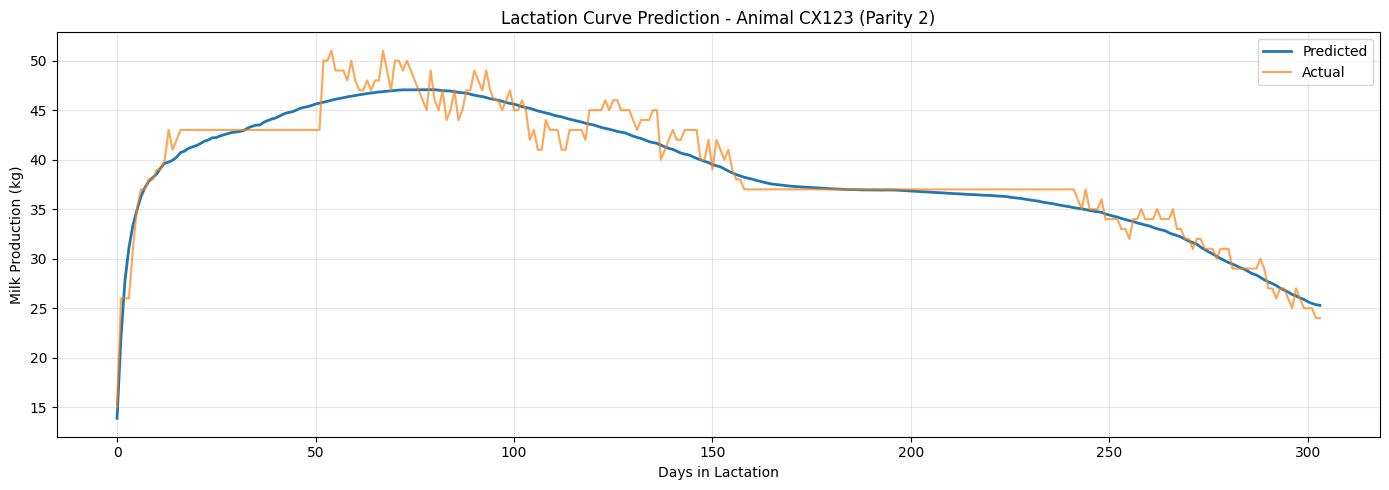


Plot shows prediction for animal CX123


In [20]:
# Simple plot using result's built-in plotting method
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# Attach actual labels from dataset item for comparison
result.attach_actual_labels(item)
result.plot_prediction(ax=ax, show_input=True)

# Add animal metadata to title
ax.set_title(f"Lactation Curve Prediction - Animal {animal_data['animal_id']} (Parity {animal_data['parity']})")
plt.tight_layout()
plt.show()

print(f"\nPlot shows prediction for animal {animal_data['animal_id']}")

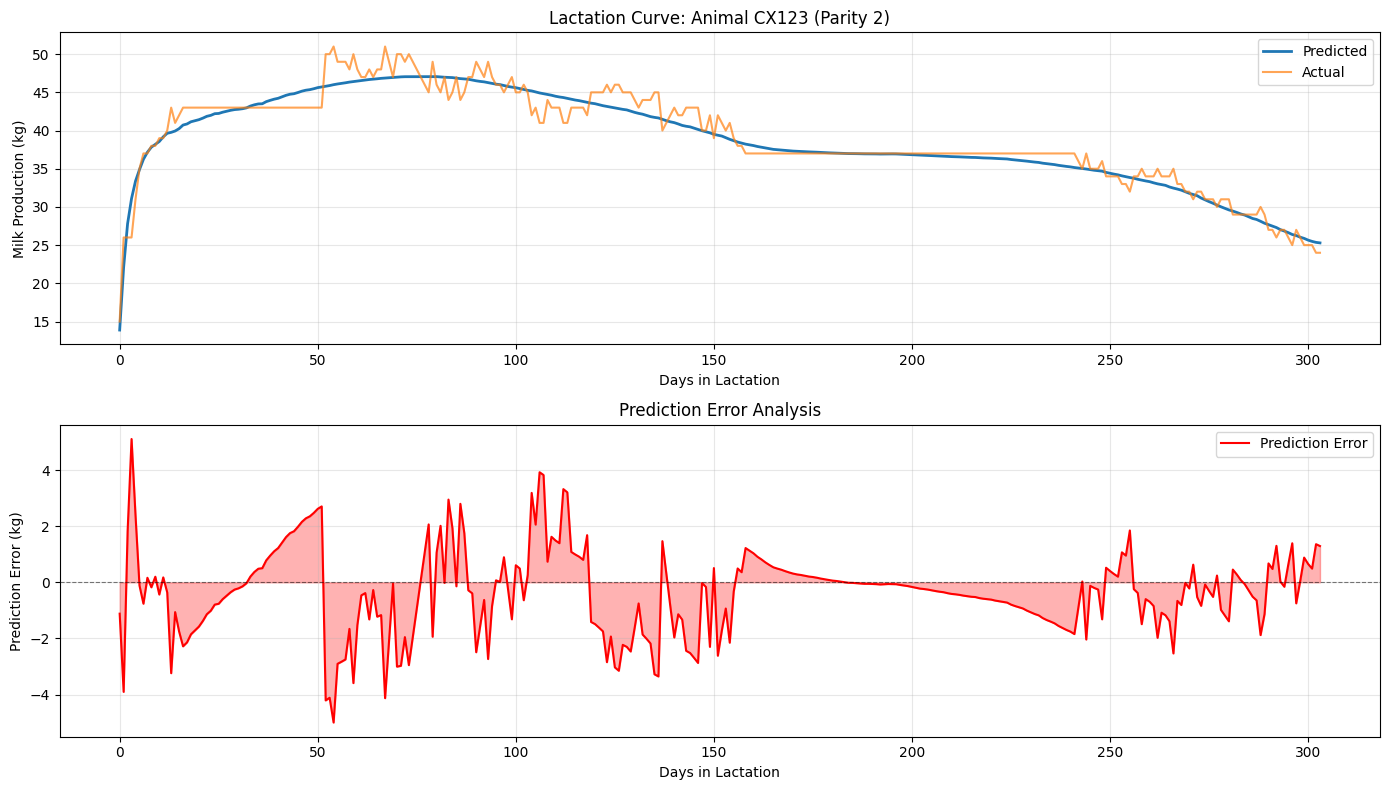


Error metrics:
  MAE (Mean Absolute Error): 1.13 kg
  RMSE (Root Mean Squared Error): 1.52 kg


In [21]:
# Detailed plot with error analysis using result methods
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: Prediction vs actual
result.plot_prediction(ax=axes[0], show_input=True)
axes[0].set_title(f'Lactation Curve: Animal {animal_data["animal_id"]} (Parity {animal_data["parity"]})')

# Bottom: Error analysis
result.plot_error_analysis(ax=axes[1])

plt.tight_layout()
plt.show()

# Calculate error metrics
actual_milk = item['labels'] * 80.0
predicted_milk = result.predictions.squeeze()
residuals = predicted_milk - actual_milk
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals**2))

print(f"\nError metrics:")
print(f"  MAE (Mean Absolute Error): {mae:.2f} kg")
print(f"  RMSE (Root Mean Squared Error): {rmse:.2f} kg")

## Summary

This notebook demonstrated the complete lactation autoencoder pipeline:

1. **Config-driven setup**: All paths and settings from `config.yaml`
2. **Data loading**: `LactationPKLSource` loads JSON + herd statistics
3. **Transform pipeline**: Imputation → Tokenization → Normalization
4. **Dataset**: `LactationDataset` structures data with features/labels
5. **DataLoader**: Batch processing with custom collate function
6. **Model loading**: `LactationAutoencoderModel` wraps TensorFlow SavedModel
7. **Prediction**: Three-level output (raw/base/rich) with visualization

**Key achievements:**
- ✅ Config-driven architecture (no hardcoded paths)
- ✅ Transform pipeline reads framework from config automatically
- ✅ Standard feature/label structure for model compatibility
- ✅ Model successfully predicts lactation curves
- ✅ Built-in visualization and error metrics

**Results on test animal:**
- MAE: ~1.13 kg, RMSE: ~1.52 kg
- Model accurately captures lactation curve shape and trend

## Section 8: Unity Catalog Model Registration

Now that we have a trained model, let's register it to Unity Catalog for version control, governance, and deployment.

### Step 1: Register Model to Unity Catalog

The `register_to_unity_catalog()` method handles the complete workflow:
1. Auto-generates MLflow signature from dataset
2. Creates input example
3. Logs model weights (TensorFlow SavedModel)
4. Logs config.yaml as artifact (experiment settings)
5. Logs pyproject.toml as artifact (project settings, dependencies)
6. Registers to Unity Catalog with alias

> **Note**: This cell requires Databricks Unity Catalog credentials and is shown for reference only.

```python
import mlflow

from lactation_autoencoder.models.lactation_unity_catalog import LactationSavedModelWrapper

# Set MLflow to use Unity Catalog registry
mlflow.set_registry_uri("databricks-uc")

# Register model with auto-generated signature
# The dataset is used to infer the signature automatically
print("Registering model to Unity Catalog...")

model_version = model.register_to_unity_catalog(
    dataset=dataset,
    catalog="projects",
    schema="bovi_core",
    model_name="lactation_autoencoder",
    alias="Champion",
    description="Lactation autoencoder for milk production reconstruction",
    pyfunc_wrapper_class=LactationSavedModelWrapper,
    tags={
        "task": "reconstruction",
        "mae": f"{mae:.2f}",
        "rmse": f"{rmse:.2f}",
    },
    n_samples=1,  # Use 1 sample for signature inference
    verbose=True
)

print(f"\nModel registered successfully!")
print(f"   Version: {model_version.version}")
print(f"   Alias: Champion")
print(f"   URI: models:/projects.bovi_core.lactation_autoencoder@Champion")
```

### Step 2: Load Model from Unity Catalog

The `load_from_unity_catalog()` class method reconstructs the complete model + predictor:
1. Downloads TensorFlow weights from UC
2. Downloads config.yaml and pyproject.toml artifacts
3. Reconstructs Config object from both artifacts
4. Creates Predictor from config
5. Creates Model with predictor
6. Returns fully functional model with three-level returns

> **Note**: This cell requires Databricks Unity Catalog credentials and is shown for reference only.

```python
# Load model from Unity Catalog - ONE LINE!
print("Loading model from Unity Catalog...")
from lactation_autoencoder import LactationAutoencoderModel

loaded_model = LactationAutoencoderModel.load_from_unity_catalog(
    model_uri="models:/projects.bovi_core.lactation_autoencoder@Champion"
)

print("\nModel loaded from UC and ready to use!")
print(f"   Model has predictor: {loaded_model.predictor is not None}")
print(f"   Model has config: {loaded_model.config is not None}")
print(f"   Three-level returns available: raw/base/rich")
```

### Step 3: Test Loaded Model

Verify that the loaded model works identically to the original:
- Same predictions
- Same three-level returns (raw/base/rich)
- Same plotting methods

> **Note**: This cell requires a Unity Catalog-loaded model and is shown for reference only.

```python
# Test loaded model with same input
print("Testing loaded model...")

loaded_result = loaded_model.predict(prediction_input, return_format='rich')

print(f"Prediction successful!")
print(f"   Result type: {type(loaded_result).__name__}")
print(f"   Prediction shape: {loaded_result.predictions.shape}")

# Compare predictions
prediction_diff = np.abs(result.predictions - loaded_result.predictions)
max_diff = np.max(prediction_diff)
mean_diff = np.mean(prediction_diff)

print(f"\nPrediction comparison (original vs UC-loaded):")
print(f"   Max difference: {max_diff:.6f} kg")
print(f"   Mean difference: {mean_diff:.6f} kg")
```

### Step 3a: Download Weights Locally (Optional)

For persistent local storage, use `download_weights=True`. This copies the model weights to your local experiment directory so they survive kernel restarts and can be loaded offline.

**Two ways to load from Unity Catalog:**

1. **Full URI approach:**
```python
model = LactationAutoencoderModel.load_from_unity_catalog(
    model_uri="models:/projects.bovi_core.lactation_autoencoder@Champion"
)
```

2. **Component-based approach:**
```python
model = LactationAutoencoderModel.load_from_unity_catalog(
    catalog="projects",
    schema="bovi_core",
    model_name="lactation_autoencoder",
    alias="Champion"
)
```

Both are equivalent - use whichever is more convenient!

> **Note**: This cell requires Databricks Unity Catalog credentials and is shown for reference only.

```python
# Load model with weights downloaded locally for persistence
# This example uses component-based loading (catalog/schema/model_name/alias)
# instead of the full model_uri - both approaches work!

print("Loading model using component-based approach with local weights download...")

local_model = LactationAutoencoderModel.load_from_unity_catalog(
    # Component-based approach (alternative to model_uri):
    catalog="projects",
    schema="bovi_core",
    model_name="lactation_autoencoder",
    alias="Champion",
    download_weights=True  # Copy weights to local experiment directory
)

print("\nModel loaded with local weights!")
print(f"   Weights path: {local_model.weights_path}")
print(f"   Config: {local_model.config.experiment.config_file_path}")
```

> **Note**: This cell requires a locally-downloaded Unity Catalog model and is shown for reference only.

```python
# Test locally downloaded model works correctly
print("Testing locally downloaded model...")

local_result = local_model.predict(prediction_input, return_format='rich')

print(f"Local model prediction successful!")
print(f"   Result type: {type(local_result).__name__}")
print(f"   Prediction shape: {local_result.predictions.shape}")

# Compare with original UC-loaded model (should be identical)
local_vs_uc_diff = np.abs(loaded_result.predictions - local_result.predictions)
max_diff = np.max(local_vs_uc_diff)

print(f"\nComparison (UC-cached vs locally-downloaded):")
print(f"   Max difference: {max_diff:.6f} kg")
```

> **Note**: This cell requires a Unity Catalog-loaded model and is shown for reference only.

```python
# Test plotting methods
fig, ax = plt.subplots(figsize=(14, 5))

loaded_result.attach_actual_labels(item)
loaded_result.plot_prediction(ax=ax, show_input=True)

ax.set_title(f"UC-Loaded Model Prediction - Animal {animal_data['animal_id']}")
plt.tight_layout()
plt.show()

print("Plotting methods work correctly!")
print("\nUnity Catalog integration complete!")
```

### Summary: Unity Catalog Workflow

The Unity Catalog integration provides a simple, config-driven workflow:

**Registration** (one method call):
```python
model.register_to_unity_catalog(
    dataset=dataset,  # Auto-generates signature
    alias="Champion",
    description="..."
)
```

**What gets saved**:
- ✅ TensorFlow SavedModel weights (full model object)
- ✅ config.yaml artifact (model/experiment settings)
- ✅ pyproject.toml artifact (project settings, dependencies)
- ✅ MLflow signature (auto-inferred from dataset)
- ✅ Input example (from dataset)
- ✅ Tags and metadata

**Loading** (one method call):
```python
loaded_model = LactationAutoencoderModel.load_from_unity_catalog(
    model_uri="models:/catalog.schema.model@alias"
)
```

**What gets reconstructed**:
- ✅ TensorFlow SavedModel loaded
- ✅ Config object from config.yaml + pyproject.toml
- ✅ Predictor instantiated from config
- ✅ Model + Predictor connected
- ✅ Three-level returns (raw/base/rich) work
- ✅ All plotting methods available

**Key Benefits**:
- **Simple**: No custom wrappers or serialization
- **Config-driven**: Everything reconstructed from artifacts
- **Reproducible**: pyproject.toml captures exact environment
- **Generic**: Works for TensorFlow and PyTorch (YOLO) models
- **Complete**: Full model functionality after loading
- **Governance**: Version control and deployment via UC

**UC stores weights + config + project info** - the magic happens in the reconstruction!